# C2: Supervision-Only Control — dSprites Pipeline Walkthrough

**Purpose.** This notebook walks through the entire C2 pipeline from raw dataset to objective
calculation. It is purely **educational** — no training loop, no checkpoints.

**What C2 is.** C2 is the _supervision-only control_ in Regime C of the research proposal.
It keeps a standard β-VAE backbone **unchanged** and adds two small auxiliary predictor heads
that predict the ground-truth `scale` (6 classes) and `orientation` (40 classes) labels from
the encoder mean `μ(x)`. These heads are dropped at test time — composition still happens in
the same shared latent space. C2 therefore isolates the effect of _label supervision alone_,
before introducing the explicit factor-addressable latent partitioning of Regime D (SP-VAE).

**What this notebook covers:**
1. Download and explore the dSprites dataset
2. Visualise the `scale` and `orientation` factor structure
3. Define the C2 architecture (Encoder → Decoder + two AuxPredictors)
4. Run a single forward pass and inspect every intermediate tensor
5. PCA plots of the bottleneck `μ` vectors
6. Visualise inputs vs reconstructions
7. Compute and display every term in the C2 objective

> **Note on random weights.** The model is instantiated with random weights, so
> reconstructions will look like noise and losses will be large. That is expected and by
> design — the goal here is to understand the _pipeline shape_, not to obtain good outputs.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
from sklearn.decomposition import PCA
from pathlib import Path
import urllib.request

torch.manual_seed(0)
np.random.seed(0)

print(f"PyTorch {torch.__version__}")

PyTorch 2.7.0+cu128


---
## § 1 — Download dSprites

dSprites is a procedurally generated benchmark dataset from DeepMind.
Each image is a **64×64 binary sprite** (white shape on black background).
The entire dataset is a single 75 MB `.npz` file.

In [2]:
CACHE_DIR = Path.home() / ".cache" / "dsprites"
CACHE_DIR.mkdir(parents=True, exist_ok=True)
NPZ_PATH = CACHE_DIR / "dsprites.npz"

URL = ("https://github.com/google-deepmind/dsprites-dataset/raw/master/"
       "dsprites_ndarray_co1sh3sc6or40x32y32_64x64.npz")

if not NPZ_PATH.exists():
    print("Downloading dSprites (~75 MB) …")
    urllib.request.urlretrieve(URL, NPZ_PATH)
    print("Done.")
else:
    print(f"Using cached file: {NPZ_PATH}")

data = np.load(NPZ_PATH, allow_pickle=True, encoding="latin1")
print("\nKeys in the NPZ file:")
for k in data.files:
    v = data[k]
    print(f"  {k:25s}  shape={v.shape}  dtype={v.dtype}")

Done.

Keys in the NPZ file:
  metadata                   shape=()  dtype=object
  imgs                       shape=(737280, 64, 64)  dtype=uint8
  latents_classes            shape=(737280, 6)  dtype=int64
  latents_values             shape=(737280, 6)  dtype=float64


---
## § 2 — Dataset Structure

dSprites is a **fully factorial** dataset: every combination of the generative factors
is present exactly once. The five independent factors are:

| Factor | # Values | Notes |
|--------|----------|-----------|
| color | 1 | Always white — no variation |
| **shape** | 3 | 0 = square, 1 = ellipse, 2 = heart |
| **scale** | **6** | Physical sizes ≈ 0.5 – 1.0 (uniform) |
| **orientation** | **40** | Angles 0° – 351° in 9° steps |
| posX | 32 | Horizontal position |
| posY | 32 | Vertical position |

Total images: 3 × 6 × 40 × 32 × 32 = **737,280**

C2 supervises two of these factors: **scale** (6-class) and **orientation** (40-class).
The ground-truth integer labels come from `latents_classes`, a (737280, 6) array where
columns correspond to (color, shape, scale, orientation, posX, posY).

In [3]:
imgs          = data["imgs"]           # (737280, 64, 64)  uint8 {0,1}
latents_cls   = data["latents_classes"] # (737280, 6)       int   — factor indices
latents_vals  = data["latents_values"]  # (737280, 6)       float — physical values
metadata      = data["metadata"][()]

# Column layout
COL_COLOR, COL_SHAPE, COL_SCALE, COL_ORIENT, COL_POSX, COL_POSY = range(6)

print("Factor physical-value ranges:")
factor_names = ["color", "shape", "scale", "orientation", "posX", "posY"]
for i, name in enumerate(factor_names):
    vals = np.unique(latents_vals[:, i])
    print(f"  {name:12s}  {len(vals):3d} values   "
          f"[{vals[0]:.4f} … {vals[-1]:.4f}]")

print("\nScale physical values:")
print(" ", np.unique(latents_vals[:, COL_SCALE]))
print("\nOrientation physical values (radians, first 8 shown):")
orient_vals = np.unique(latents_vals[:, COL_ORIENT])
print(" ", np.round(orient_vals[:8], 4), "…")
print(f"  step = {orient_vals[1] - orient_vals[0]:.4f} rad  "
      f"({np.degrees(orient_vals[1] - orient_vals[0]):.1f}°)")

Factor physical-value ranges:
  color           1 values   [1.0000 … 1.0000]
  shape           3 values   [1.0000 … 3.0000]
  scale           6 values   [0.5000 … 1.0000]
  orientation    40 values   [0.0000 … 6.2832]
  posX           32 values   [0.0000 … 1.0000]
  posY           32 values   [0.0000 … 1.0000]

Scale physical values:
  [0.5 0.6 0.7 0.8 0.9 1. ]

Orientation physical values (radians, first 8 shown):
  [0.     0.1611 0.3222 0.4833 0.6444 0.8055 0.9666 1.1278] …
  step = 0.1611 rad  (9.2°)


---
## § 3 — Scale (6 classes)

Scale class 0 is the smallest sprite (~50% of the image span);
scale class 5 is the largest (~100%). The 6 discrete levels are uniformly spaced.
Below we fix shape=square, orientation=0, posX=posY=16 and vary only scale.

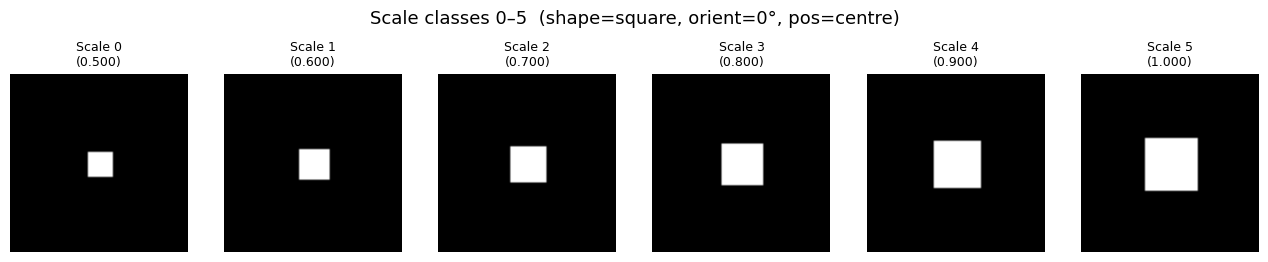

In [4]:
def find_index(shape_idx, scale_idx, orient_idx, posx_idx=16, posy_idx=16):
    """Return the dataset row index for a given combination of factor class indices."""
    mask = (
        (latents_cls[:, COL_SHAPE]  == shape_idx)  &
        (latents_cls[:, COL_SCALE]  == scale_idx)  &
        (latents_cls[:, COL_ORIENT] == orient_idx) &
        (latents_cls[:, COL_POSX]   == posx_idx)   &
        (latents_cls[:, COL_POSY]   == posy_idx)
    )
    idxs = np.where(mask)[0]
    assert len(idxs) == 1, f"Expected 1 match, got {len(idxs)}"
    return idxs[0]

scale_vals_phys = np.unique(latents_vals[:, COL_SCALE])

fig, axes = plt.subplots(1, 6, figsize=(13, 2.5))
fig.suptitle("Scale classes 0–5  (shape=square, orient=0°, pos=centre)",
             fontsize=13, y=1.03)
for sc in range(6):
    idx = find_index(shape_idx=0, scale_idx=sc, orient_idx=0)
    axes[sc].imshow(imgs[idx], cmap="gray", vmin=0, vmax=1)
    axes[sc].set_title(f"Scale {sc}\n({scale_vals_phys[sc]:.3f})", fontsize=9)
    axes[sc].axis("off")
plt.tight_layout()
plt.show()

---
## § 4 — Orientation (40 classes)

Orientation sweeps 0° to 351° in uniform 9° steps, giving 40 discrete classes.
We show two views:
- **(a) Image grid** — 5 rows × 8 cols, all 40 orientations of a fixed square
- **(b) Polar diagram** — spokes at each of the 40 angles, confirming uniform coverage

/tmp/ipykernel_1210784/3193763564.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


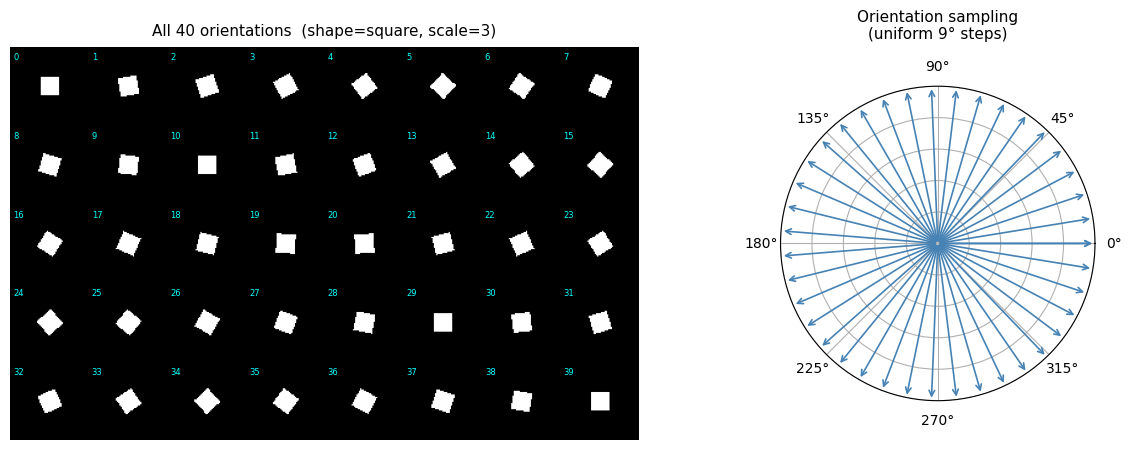

In [6]:
orient_vals_phys = np.unique(latents_vals[:, COL_ORIENT])

fig = plt.figure(figsize=(14, 7))
gs = gridspec.GridSpec(1, 2, width_ratios=[2, 1], wspace=0.3)

# --- (a) image grid ---
ax_grid = fig.add_subplot(gs[0])
ax_grid.axis("off")
ax_grid.set_title("All 40 orientations  (shape=square, scale=3)",
                  fontsize=11, pad=8)

rows, cols = 5, 8
tile_size = 64
canvas = np.zeros((rows * tile_size, cols * tile_size))
for ori in range(40):
    idx = find_index(shape_idx=0, scale_idx=3, orient_idx=ori)
    r, c = divmod(ori, cols)
    canvas[r*tile_size:(r+1)*tile_size, c*tile_size:(c+1)*tile_size] = imgs[idx]
ax_grid.imshow(canvas, cmap="gray", vmin=0, vmax=1)
# row/col labels
for r in range(rows):
    for c in range(cols):
        ori = r * cols + c
        ax_grid.text(c*tile_size + 2, r*tile_size + 10,
                     f"{ori}", color="cyan", fontsize=6)

# --- (b) polar diagram ---
ax_polar = fig.add_subplot(gs[1], projection="polar")
ax_polar.set_title("Orientation sampling\n(uniform 9° steps)",
                   fontsize=11, pad=15)
for ori in range(40):
    angle = orient_vals_phys[ori]   # radians
    ax_polar.annotate("", xy=(angle, 1.0), xytext=(0, 0),
                      arrowprops=dict(arrowstyle="->", color="steelblue", lw=1.2))
ax_polar.set_yticklabels([])
ax_polar.set_xticks(np.linspace(0, 2*np.pi, 8, endpoint=False))
ax_polar.set_xticklabels([f"{int(np.degrees(a))}°"
                           for a in np.linspace(0, 2*np.pi, 8, endpoint=False)])
plt.tight_layout()
plt.show()

---
## § 5 — Combined Factor Grid: Scale × Shape

This 6 × 3 grid shows **every (scale, shape) combination** at fixed orientation=0, posX=posY=16.
It concretely demonstrates what the two supervised label dimensions index —
exactly the combinations that C2 must be able to predict from `μ(x)`.

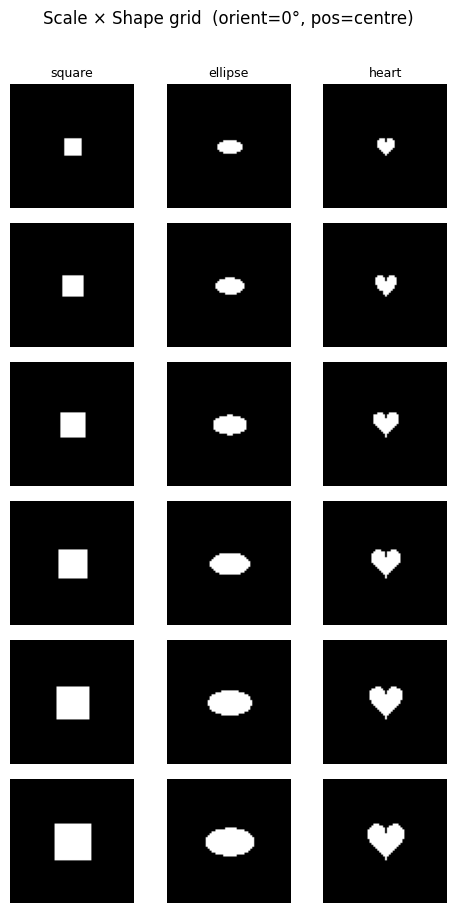

In [7]:
shape_names = ["square", "ellipse", "heart"]
n_scales, n_shapes = 6, 3

fig, axes = plt.subplots(n_scales, n_shapes, figsize=(5, 9))
fig.suptitle("Scale × Shape grid  (orient=0°, pos=centre)",
             fontsize=12, y=1.01)

for sc in range(n_scales):
    for sh in range(n_shapes):
        idx = find_index(shape_idx=sh, scale_idx=sc, orient_idx=0)
        axes[sc, sh].imshow(imgs[idx], cmap="gray", vmin=0, vmax=1)
        axes[sc, sh].axis("off")
        if sc == 0:
            axes[sc, sh].set_title(shape_names[sh], fontsize=9)
        if sh == 0:
            axes[sc, sh].set_ylabel(f"sc={sc}", fontsize=8, rotation=0,
                                    labelpad=28, va="center")

plt.tight_layout()
plt.show()

---
## § 6 — C2 Model Architecture

```
C2: supervision-only control

input x  (B, 1, 64, 64)
  |
  v
+------------------------------------------+
|              Encoder                     |
|  Conv1: 1→32  k4 s2  →  (B,  32, 32, 32)|
|  Conv2: 32→64 k4 s2  →  (B,  64, 16, 16)|
|  Conv3: 64→128 k4 s2 →  (B, 128,  8,  8)|
|  Flatten → FC → μ(x), logvar(x)          |
|  both ∈ (B, latent_dim=10)               |
+------------------------------------------+
         |              \
         |  reparam.     \  training-only supervision branches
         v               v
    z (B, 10)     h = μ(x)  (B, 10)   ← deterministic, no noise
         |               |          |
         v               v          v
  +------------+  +----------+  +-------------+
  |  Decoder   |  | g_scale  |  | g_orient    |
  | ConvT ×3   |  | MLP→6cls |  | MLP→40cls   |
  | → (B,1,64) |  +----------+  +-------------+
  +------------+
         |
         v
   x_hat (B, 1, 64, 64)
```

**Key design choice.** The auxiliary predictors take `μ(x)` rather than a sampled `z`.
This makes the supervised signal **deterministic** — gradient does not flow through the
sampling noise, giving a cleaner loss landscape for the label branches.

In [8]:
LATENT_DIM = 10


class Encoder(nn.Module):
    """CNN encoder: (B, 1, 64, 64) → mu (B, L), logvar (B, L)."""

    def __init__(self, latent_dim: int = LATENT_DIM):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1),   # → 32×32
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),  # → 16×16
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1), # →  8×8
            nn.ReLU(),
        )
        self.flat_dim = 128 * 8 * 8   # = 8192
        self.fc_mu     = nn.Linear(self.flat_dim, latent_dim)
        self.fc_logvar = nn.Linear(self.flat_dim, latent_dim)

    def forward(self, x):
        h = self.conv(x).flatten(1)   # (B, 8192)
        return self.fc_mu(h), self.fc_logvar(h)

In [9]:
class Decoder(nn.Module):
    """CNN decoder: z (B, L) → x_hat (B, 1, 64, 64) in [0, 1]."""

    def __init__(self, latent_dim: int = LATENT_DIM):
        super().__init__()
        self.flat_dim = 128 * 8 * 8
        self.fc = nn.Linear(latent_dim, self.flat_dim)
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),  # → 16×16
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),   # → 32×32
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1),    # → 64×64
            nn.Sigmoid(),
        )

    def forward(self, z):
        h = self.fc(z).view(-1, 128, 8, 8)
        return self.deconv(h)

In [10]:
class AuxPredictor(nn.Module):
    """Small MLP for factor prediction: μ (B, L) → logits (B, num_classes)."""

    def __init__(self, latent_dim: int, num_classes: int, hidden: int = 32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, num_classes),
        )

    def forward(self, mu):
        return self.net(mu)

In [11]:
class C2VAE(nn.Module):
    """
    C2: β-VAE backbone + auxiliary scale & orientation predictors.

    At train time  : all four components contribute to the loss.
    At test time   : g_scale and g_orient are discarded; composition uses
                     the standard VAE latent space exactly as before.
    """

    N_SCALE  = 6    # dSprites scale classes
    N_ORIENT = 40   # dSprites orientation classes

    def __init__(self, latent_dim: int = LATENT_DIM):
        super().__init__()
        self.encoder   = Encoder(latent_dim)
        self.decoder   = Decoder(latent_dim)
        self.g_scale   = AuxPredictor(latent_dim, self.N_SCALE)
        self.g_orient  = AuxPredictor(latent_dim, self.N_ORIENT)

    @staticmethod
    def reparameterize(mu, logvar):
        """z = μ + σ ⊙ ε,   ε ~ N(0, I)."""
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + std * eps

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z          = self.reparameterize(mu, logvar)
        x_hat      = self.decoder(z)
        # Auxiliary branches use μ (deterministic), not the stochastic z
        scale_logits  = self.g_scale(mu)
        orient_logits = self.g_orient(mu)
        return x_hat, mu, logvar, scale_logits, orient_logits


model = C2VAE(latent_dim=LATENT_DIM)
model.eval()
print(model)

C2VAE(
  (encoder): Encoder(
    (conv): Sequential(
      (0): Conv2d(1, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (3): ReLU()
      (4): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (5): ReLU()
    )
    (fc_mu): Linear(in_features=8192, out_features=10, bias=True)
    (fc_logvar): Linear(in_features=8192, out_features=10, bias=True)
  )
  (decoder): Decoder(
    (fc): Linear(in_features=10, out_features=8192, bias=True)
    (deconv): Sequential(
      (0): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): ReLU()
      (2): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (3): ReLU()
      (4): ConvTranspose2d(32, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (5): Sigmoid()
    )
  )
  (g_scale): AuxPredictor(
    (net): Sequential(
      (0): Linear(in_features=

---
## § 7 — Single Forward Pass

We sample a batch of 16 images uniformly from the dataset and run them through the
untrained C2VAE. The table below traces every tensor through the network.

In [12]:
BATCH_SIZE = 16
rng        = np.random.default_rng(seed=42)
batch_idxs = rng.choice(len(imgs), size=BATCH_SIZE, replace=False)

# Images: float32 in [0, 1], shape (B, 1, 64, 64)
x_np  = imgs[batch_idxs].astype(np.float32)[:, None, :, :]
x     = torch.from_numpy(x_np)

# Ground-truth labels (int64 for cross_entropy)
y_scale  = torch.tensor(latents_cls[batch_idxs, COL_SCALE],  dtype=torch.long)
y_orient = torch.tensor(latents_cls[batch_idxs, COL_ORIENT], dtype=torch.long)

with torch.no_grad():
    x_hat, mu, logvar, scale_logits, orient_logits = model(x)

print("Tensor shapes through the network:")
print(f"  {'Input x':<25s} {tuple(x.shape)}")
print(f"  {'Encoder μ':<25s} {tuple(mu.shape)}")
print(f"  {'Encoder logvar':<25s} {tuple(logvar.shape)}")
print(f"  {'Sampled z = reparam(μ,σ)':<25s} (same as μ, not stored separately)")
print(f"  {'Reconstruction x̂':<25s} {tuple(x_hat.shape)}")
print(f"  {'Scale logits ŷ_s':<25s} {tuple(scale_logits.shape)}   (→ 6 classes)")
print(f"  {'Orient logits ŷ_o':<25s} {tuple(orient_logits.shape)}  (→ 40 classes)")
print()
print(f"  y_scale  (ground truth): {y_scale.tolist()}")
print(f"  y_orient (ground truth): {y_orient.tolist()}")

Tensor shapes through the network:
  Input x                   (16, 1, 64, 64)
  Encoder μ                 (16, 10)
  Encoder logvar            (16, 10)
  Sampled z = reparam(μ,σ)  (same as μ, not stored separately)
  Reconstruction x̂         (16, 1, 64, 64)
  Scale logits ŷ_s          (16, 6)   (→ 6 classes)
  Orient logits ŷ_o         (16, 40)  (→ 40 classes)

  y_scale  (ground truth): [1, 1, 1, 1, 0, 5, 3, 1, 2, 0, 1, 1, 3, 5, 1, 3]
  y_orient (ground truth): [35, 24, 27, 9, 22, 31, 19, 28, 5, 36, 31, 21, 18, 22, 37, 25]


---
## § 8 — Input Visualisation

The 16 input images with their ground-truth `(scale, orient)` class labels.

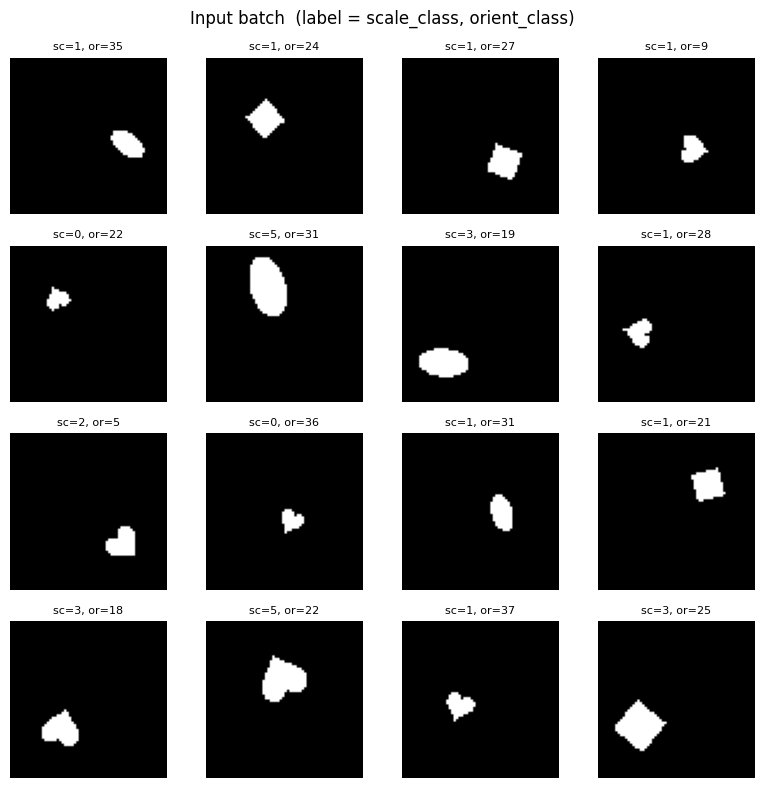

In [13]:
fig, axes = plt.subplots(4, 4, figsize=(8, 8))
fig.suptitle("Input batch  (label = scale_class, orient_class)", fontsize=12)
for i, ax in enumerate(axes.flat):
    ax.imshow(x_np[i, 0], cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"sc={y_scale[i].item()}, or={y_orient[i].item()}",
                 fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.show()

---
## § 9 — Bottleneck: PCA on `μ(x)`

We pass 500 images through the encoder and collect the mean vectors `μ ∈ ℝ¹⁰`.
PCA reduces them to 2D for visualisation.

**What to look for (after training):**
- If scale and orientation are well-represented, nearby points in PC space should share
  the same factor values.
- With random weights (now), the structure is meaningless — but the code path is identical
  to what runs during evaluation of a trained model.

Two scatter plots are shown side-by-side: one coloured by **scale class**, one by
**orientation class** (using a circular colormap to reflect the periodic nature of angles).

PCA: PC1 explains 22.1%,  PC2 explains 19.8%


/tmp/ipykernel_1210784/2611919472.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap6 = plt.cm.get_cmap("tab10", 6)


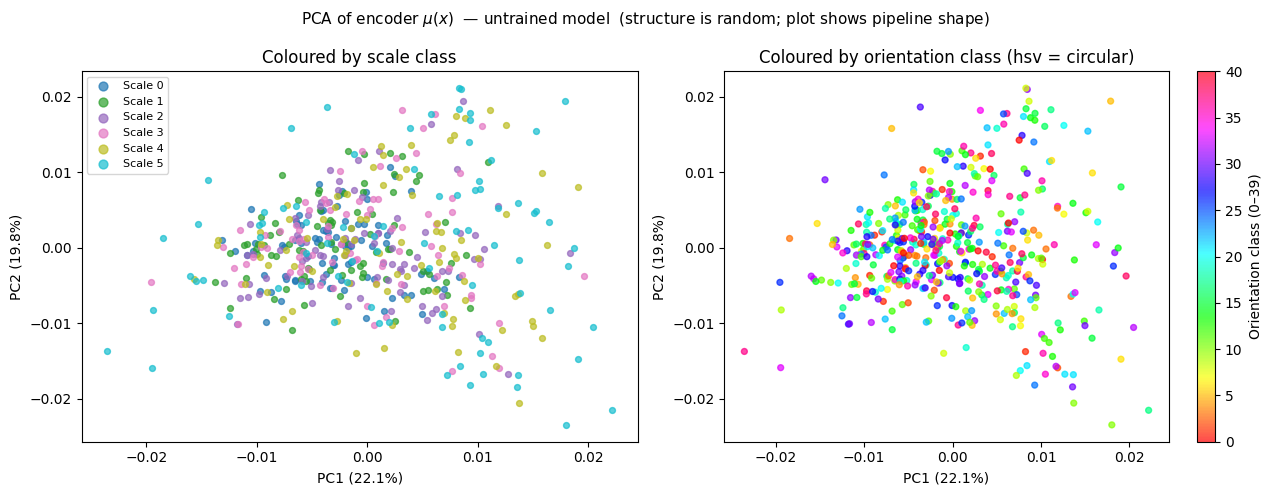

In [14]:
N_PCA = 500
# Stratified across all 6 scale classes
per_class = N_PCA // 6
pca_idxs  = []
for sc in range(6):
    pool = np.where(latents_cls[:, COL_SCALE] == sc)[0]
    pca_idxs.append(rng.choice(pool, size=per_class, replace=False))
pca_idxs = np.concatenate(pca_idxs)

x_pca  = torch.from_numpy(imgs[pca_idxs].astype(np.float32)[:, None, :, :])
sc_pca = latents_cls[pca_idxs, COL_SCALE]
or_pca = latents_cls[pca_idxs, COL_ORIENT]

with torch.no_grad():
    mu_pca, _ = model.encoder(x_pca)
mu_pca = mu_pca.numpy()

pca     = PCA(n_components=2)
mu_2d   = pca.fit_transform(mu_pca)
var_exp = pca.explained_variance_ratio_ * 100
print(f"PCA: PC1 explains {var_exp[0]:.1f}%,  PC2 explains {var_exp[1]:.1f}%")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(r"PCA of encoder $\mu(x)$  — untrained model"
             "  (structure is random; plot shows pipeline shape)",
             fontsize=11)

# --- colour by scale ---
cmap6 = plt.cm.get_cmap("tab10", 6)
for sc in range(6):
    mask = sc_pca == sc
    ax1.scatter(mu_2d[mask, 0], mu_2d[mask, 1],
                c=[cmap6(sc)], label=f"Scale {sc}", s=18, alpha=0.7)
ax1.set_xlabel(f"PC1 ({var_exp[0]:.1f}%)")
ax1.set_ylabel(f"PC2 ({var_exp[1]:.1f}%)")
ax1.set_title("Coloured by scale class")
ax1.legend(loc="best", fontsize=8, markerscale=1.5)

# --- colour by orientation (circular) ---
sc2 = ax2.scatter(mu_2d[:, 0], mu_2d[:, 1],
                  c=or_pca, cmap="hsv", s=18, alpha=0.7,
                  vmin=0, vmax=40)
plt.colorbar(sc2, ax=ax2, label="Orientation class (0–39)")
ax2.set_xlabel(f"PC1 ({var_exp[0]:.1f}%)")
ax2.set_ylabel(f"PC2 ({var_exp[1]:.1f}%)")
ax2.set_title("Coloured by orientation class (hsv = circular)")

plt.tight_layout()
plt.show()

---
## § 10 — Reconstruction

Top row: original inputs. Bottom row: decoder outputs from the untrained model.
The reconstructions are meaningless (random sigmoid activations) — that is expected.
After training, the decoder should faithfully reproduce the binary sprite.

In [ ]:
N_SHOW = 8
x_hat_np = x_hat.detach().numpy()

fig, axes = plt.subplots(2, N_SHOW, figsize=(14, 4))
fig.suptitle(
    "Inputs (top) vs reconstructions (bottom)\n"
    "[Untrained model — bottom row is random noise by design]",
    fontsize=10
)
for i in range(N_SHOW):
    axes[0, i].imshow(x_np[i, 0], cmap="gray", vmin=0, vmax=1)
    axes[0, i].axis("off")
    axes[1, i].imshow(x_hat_np[i, 0], cmap="gray", vmin=0, vmax=1)
    axes[1, i].axis("off")
axes[0, 0].set_ylabel("Input",   fontsize=9, rotation=90)
axes[1, 0].set_ylabel("Reconst.", fontsize=9, rotation=90)
plt.tight_layout()
plt.show()

---
## § 11 — Objective Terms

The C2 objective has four terms:

$$
\mathcal{L}_{\text{C2}}
= \underbrace{\mathcal{L}_{\text{rec}} + \beta\,\mathcal{L}_{\text{KL}}}_{\mathcal{L}_{\text{backbone}}}
+ \lambda_s\,\mathcal{L}_{\text{scale}}
+ \lambda_o\,\mathcal{L}_{\text{orient}}
$$

We compute each term below and then combine them.

In [ ]:
# Re-run forward pass with gradient tracking enabled (for loss computation)
x_hat, mu, logvar, scale_logits, orient_logits = model(x)

B = x.shape[0]

### 11.1 — Reconstruction Loss $\mathcal{L}_{\text{rec}}$

dSprites images are **binary** (pixels ∈ {0, 1}), so we use Binary Cross-Entropy
per pixel, summed across the image and averaged over the batch:

$$
\mathcal{L}_{\text{rec}}
= -\frac{1}{B}\sum_{n=1}^{B}\sum_{i}
  \bigl[x_{n,i}\log\hat{x}_{n,i} + (1-x_{n,i})\log(1-\hat{x}_{n,i})\bigr]
$$

In [ ]:
L_rec = F.binary_cross_entropy(x_hat, x, reduction="sum") / B
print(f"L_rec  = {L_rec.item():.4f}   "
      f"(sum BCE over {64*64} pixels, averaged over batch of {B})")

### 11.2 — KL Divergence $\mathcal{L}_{\text{KL}}$

With a standard normal prior $p(z) = \mathcal{N}(0,I)$ and diagonal Gaussian posterior
$q_\phi(z\mid x) = \mathcal{N}(\mu, \text{diag}(\sigma^2))$, the KL has a closed form:

$$
\mathcal{L}_{\text{KL}}
= -\frac{1}{2B}\sum_{n=1}^{B}\sum_{j=1}^{L}
  \bigl(1 + \log\sigma_{n,j}^2 - \mu_{n,j}^2 - \sigma_{n,j}^2\bigr)
$$

In [ ]:
L_KL = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp()).sum() / B
print(f"L_KL   = {L_KL.item():.4f}   "
      f"(closed-form KL, summed over {LATENT_DIM} latent dims, averaged over batch)")

### 11.3 — Scale Auxiliary Loss $\mathcal{L}_{\text{scale}}$

$$
\mathcal{L}_{\text{scale}} = \mathrm{CE}(\hat{y}_s,\, y_s), \qquad
\hat{y}_s = g_{\text{scale}}(\mu(x)) \in \mathbb{R}^6
$$

In [ ]:
L_scale = F.cross_entropy(scale_logits, y_scale)

pred_scale = scale_logits.argmax(dim=1)
acc_scale  = (pred_scale == y_scale).float().mean().item()

print(f"L_scale = {L_scale.item():.4f}   (CE over 6 scale classes)")
print(f"  Accuracy (random weights): {acc_scale*100:.1f}%  "
      f"(chance = {100/6:.1f}%)")
print(f"  Predicted : {pred_scale.tolist()}")
print(f"  True      : {y_scale.tolist()}")

### 11.4 — Orientation Auxiliary Loss $\mathcal{L}_{\text{orient}}$

$$
\mathcal{L}_{\text{orient}} = \mathrm{CE}(\hat{y}_o,\, y_o), \qquad
\hat{y}_o = g_{\text{orient}}(\mu(x)) \in \mathbb{R}^{40}
$$

In [ ]:
L_orient = F.cross_entropy(orient_logits, y_orient)

pred_orient = orient_logits.argmax(dim=1)
acc_orient  = (pred_orient == y_orient).float().mean().item()

print(f"L_orient = {L_orient.item():.4f}   (CE over 40 orientation classes)")
print(f"  Accuracy (random weights): {acc_orient*100:.1f}%  "
      f"(chance = {100/40:.1f}%)")
print(f"  Predicted : {pred_orient.tolist()}")
print(f"  True      : {y_orient.tolist()}")

### 11.5 — Full C2 Objective

$$
\mathcal{L}_{\text{C2}}
= \mathcal{L}_{\text{rec}}
+ \beta\,\mathcal{L}_{\text{KL}}
+ \lambda_s\,\mathcal{L}_{\text{scale}}
+ \lambda_o\,\mathcal{L}_{\text{orient}}
$$

Typical starting values: `β = 4`, `λ_s = λ_o = 1`. These are ablated in the full
experimental sweep.

In [ ]:
beta  = 4.0   # β-VAE pressure on latent space
lam_s = 1.0   # scale supervision weight
lam_o = 1.0   # orientation supervision weight

L_backbone = L_rec + beta * L_KL
L_C2       = L_backbone + lam_s * L_scale + lam_o * L_orient

sep = "─" * 40
print(f"  L_rec              = {L_rec.item():>10.4f}")
print(f"  β · L_KL  (β={beta})  = {(beta * L_KL).item():>10.4f}")
print(f"  {sep}  β-VAE backbone")
print(f"  L_backbone         = {L_backbone.item():>10.4f}")
print()
print(f"  λ_s · L_scale      = {(lam_s * L_scale).item():>10.4f}")
print(f"  λ_o · L_orient     = {(lam_o * L_orient).item():>10.4f}")
print(f"  {sep}  supervision")
print(f"  L_C2               = {L_C2.item():>10.4f}")

In [ ]:
# Bar chart of the four additive components
components = {
    r"$\mathcal{L}_{\rm rec}$":            L_rec.item(),
    r"$\beta\,\mathcal{L}_{\rm KL}$":      (beta * L_KL).item(),
    r"$\lambda_s\,\mathcal{L}_{\rm scale}$": (lam_s * L_scale).item(),
    r"$\lambda_o\,\mathcal{L}_{\rm orient}$": (lam_o * L_orient).item(),
}
colours = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

fig, ax = plt.subplots(figsize=(8, 3.5))
bars = ax.barh(
    list(components.keys()),
    list(components.values()),
    color=colours, edgecolor="k", linewidth=0.6
)
for bar, val in zip(bars, components.values()):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f"{val:.2f}", va="center", fontsize=10)
ax.set_xlabel("Loss value (untrained model)", fontsize=10)
ax.set_title(
    r"C2 objective components  "
    rf"($\mathcal{{L}}_{{\rm C2}} = {L_C2.item():.2f}$)",
    fontsize=11
)
ax.axvline(0, color="k", linewidth=0.8)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

---
## § 12 — Summary

### What we built

| Component | Role | Active at test time? |
|-----------|------|---------------------|
| `Encoder` | Maps image to `μ(x)`, `logvar(x)` | Yes |
| `Decoder` | Maps sampled `z` back to image | Yes |
| `g_scale` | Predicts 6-class scale label from `μ` | **No** (discarded) |
| `g_orient` | Predicts 40-class orientation label from `μ` | **No** (discarded) |

### Why C2 is "supervision-only"

- The latent space is **monolithic** — `z ∈ ℝ^L` with no partition reserved for specific factors.
- The auxiliary heads _encourage_ the encoder to preserve scale and orientation information
  in `μ`, but they do not guarantee it ends up in any particular dimension.
- Composition at test time is unchanged: you still interpolate or add latent vectors in the
  full shared space.

### What changes between random and trained weights

| Quantity | Untrained (now) | After training |
|----------|-----------------|---------------|
| Reconstructions | Random noise | Faithful binary sprites |
| `L_rec` | ~4400 | ~20–60 |
| `L_KL` | ~0.5 | ~5–15 |
| Scale accuracy | ~17% (chance) | ~70–90% |
| Orient accuracy | ~2.5% (chance) | ~30–60% |
| PCA of `μ` | Random blob | Clusters by factor value |

### Research question C2 answers

> *Does adding scale/orientation supervision to a monolithic β-VAE improve compositional
> generalisation to held-out orientation–scale combinations?*

C2's composition success rate is compared against:
- **C1** (same backbone, no supervision) — to isolate the effect of labels
- **Regime D / SP-VAE** (structured latent + same supervision) — to isolate the effect of
  explicit latent partitioning

If C2 ≈ D: supervision alone is sufficient; structural intervention buys nothing.  
If C2 < D: structural latent allocation is necessary beyond supervision — the core claim of H2.